        source         target  \
0      Detroit        Chicago   
1  Los Angeles  San Francisco   
2     New York         Boston   
3       Dallas        Houston   

                                                path  distance  hops     cost  
0                   Detroit -> Fort Wayne -> Chicago    448.36     2   648.36  
1  Los Angeles -> Bakersfield -> Fresno -> San Jo...    596.54     4   996.54  
2                                 New York -> Boston    306.11     1   406.11  
3  Dallas -> Plano -> Oklahoma City -> Tulsa -> K...   2533.79     8  3333.79  


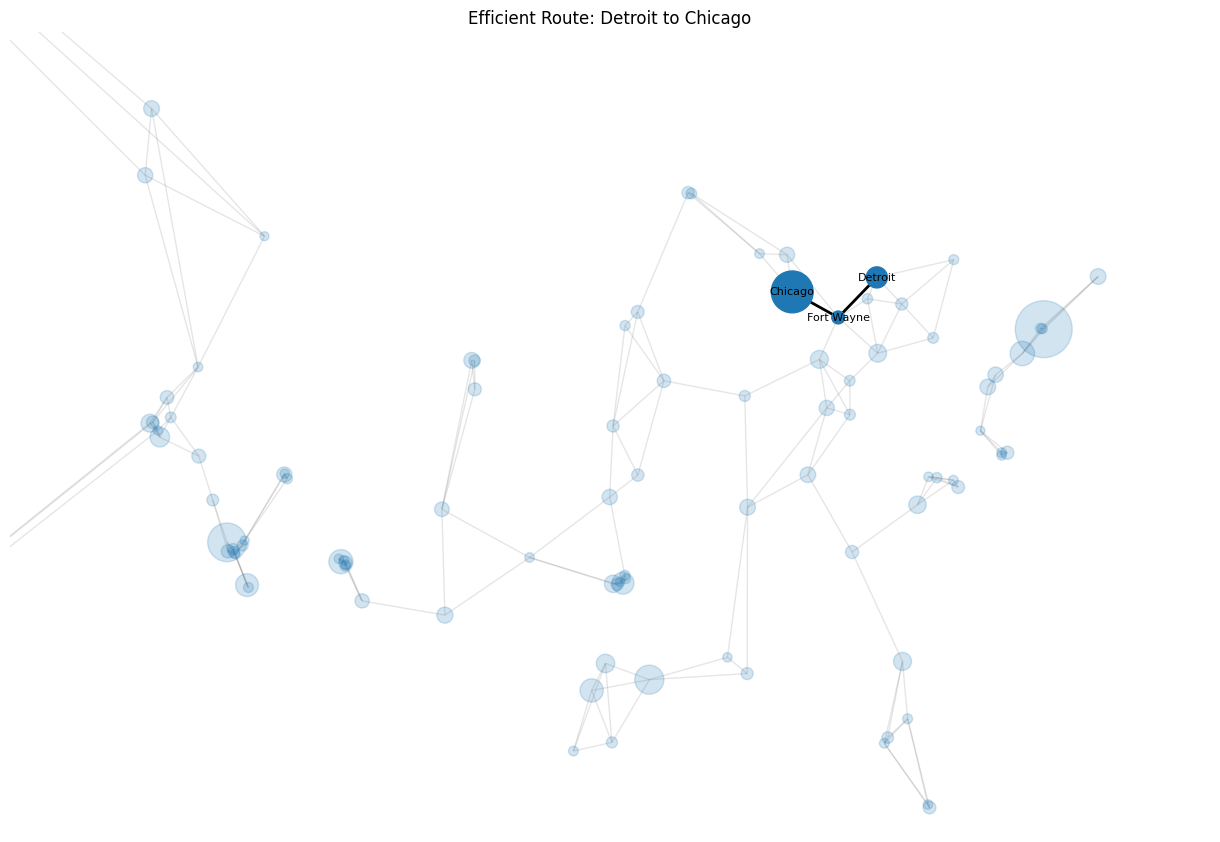

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import math

url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"

def load_data(top_n=100):
    df = pd.read_csv(url)
    df = df.sort_values(by="Population", ascending=False).head(top_n).copy()
    df = df.drop_duplicates(subset=["City"])
    df = df.reset_index(drop=True)
    return df

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def add_nodes(G, df):
    for _, row in df.iterrows():
        G.add_node(
            row["City"],
            pos=(row["lon"], row["lat"]),
            population=row["Population"]
        )

def build_knn_graph(df, k=3):
    G = nx.Graph()
    add_nodes(G, df)

    for i in range(len(df)):
        row1 = df.iloc[i]
        distances = []

        for j in range(len(df)):
            if i != j:
                row2 = df.iloc[j]
                d = haversine(row1["lat"], row1["lon"], row2["lat"], row2["lon"])
                distances.append((d, row2["City"]))

        distances.sort(key=lambda x: x[0])

        for d, city in distances[:k]:
            G.add_edge(row1["City"], city, weight=d)

    return G

def route_distance(G, path):
    total = 0
    for i in range(len(path) - 1):
        total += G[path[i]][path[i + 1]]["weight"]
    return total

def route_cost(G, path, alpha=1.0, beta=100.0):
    distance = route_distance(G, path)
    hops = len(path) - 1
    return alpha * distance + beta * hops

def analyze_route(G, source, target, alpha=1.0, beta=100.0):
    if source not in G.nodes or target not in G.nodes:
        return {
            "source": source,
            "target": target,
            "path": "City not in graph",
            "distance": None,
            "hops": None,
            "cost": None
        }

    if not nx.has_path(G, source, target):
        return {
            "source": source,
            "target": target,
            "path": "No path",
            "distance": None,
            "hops": None,
            "cost": None
        }

    path = nx.shortest_path(G, source=source, target=target, weight="weight")
    distance = route_distance(G, path)
    hops = len(path) - 1
    cost = route_cost(G, path, alpha=alpha, beta=beta)

    return {
        "source": source,
        "target": target,
        "path": " -> ".join(path),
        "distance": round(distance, 2),
        "hops": hops,
        "cost": round(cost, 2)
    }

def compare_routes(G, pairs, alpha=1.0, beta=100.0):
    results = []
    for source, target in pairs:
        results.append(analyze_route(G, source, target, alpha, beta))
    return pd.DataFrame(results)

def plot_route(G, source, target, title):
    if not nx.has_path(G, source, target):
        print("No path found")
        return

    path = nx.shortest_path(G, source=source, target=target, weight="weight")
    pos = nx.get_node_attributes(G, "pos")
    sizes = [G.nodes[node]["population"] / 5000 for node in G.nodes()]
    path_edges = list(zip(path, path[1:]))

    plt.figure(figsize=(12, 8))

    nx.draw(
        G,
        pos,
        node_size=sizes,
        edge_color="gray",
        alpha=0.2,
        with_labels=False
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=path,
        node_size=[G.nodes[node]["population"] / 3000 for node in path]
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        width=2
    )

    labels = {node: node for node in path}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    plt.xlim(-130, -65)
    plt.ylim(25, 50)
    plt.title(title)
    plt.show()

df = load_data(top_n=100)
G = build_knn_graph(df, k=3)

pairs = [
    ("Detroit", "Chicago"),
    ("Los Angeles", "San Francisco"),
    ("New York", "Boston"),
    ("Dallas", "Houston")
]

results = compare_routes(G, pairs, alpha=1.0, beta=100.0)
print(results)

plot_route(G, "Detroit", "Chicago", "Efficient Route: Detroit to Chicago")